# Fake News Detection using Naive Bayes

Member 02

ML Model: Multinomial Naive Bayes

Dataset: Fake and Real News Dataset

## Objective

The objective of this notebook is to develop and evaluate a Naive Bayes model for classifying news articles as Fake or Real.

In [1]:
import os
import re
import string
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded successfully.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


NLTK resources downloaded successfully.


## 1. Data Collection and Loading

The Fake.csv and True.csv files are loaded separately.  
A label is assigned to each dataset:

- Fake News = 0
- Real News = 1

In [3]:
fake_path = "../data/Fake.csv"
true_path = "../data/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake dataset shape:", fake_df.shape)
print("True dataset shape:", true_df.shape)

Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


In [4]:
print("Fake News Dataset")
display(fake_df.head())

print("Real News Dataset")
display(true_df.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Real News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
print("Fake dataset columns:", fake_df.columns.tolist())
print("True dataset columns:", true_df.columns.tolist())

Fake dataset columns: ['title', 'text', 'subject', 'date']
True dataset columns: ['title', 'text', 'subject', 'date']


In [6]:
fake_df["label"] = 0
true_df["label"] = 1

print("Labels added successfully.")

Labels added successfully.


In [7]:
df = pd.concat([fake_df, true_df], ignore_index=True)

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## 2. Initial Dataset Inspection

The dataset is inspected to identify:

- Number of records
- Available columns
- Data types
- Missing values
- Duplicate records
- Class distribution

In [8]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate Rows:
209


## 3. Handling Missing Values and Duplicate Records

The dataset contains no missing values. However, duplicate records can cause data leakage and affect model evaluation. Therefore, duplicate rows are removed before splitting the dataset.

In [9]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
removed_rows = rows_before - rows_after

print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed:", removed_rows)
print("Rows after removing duplicates:", rows_after)

Rows before removing duplicates: 44898
Duplicate rows removed: 209
Rows after removing duplicates: 44689


## 4. Preparing the Text Column

The news title and article body are combined into a single text column named content. This allows the model to learn information from both the headline and the complete news article.

In [10]:
df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["content"] = (
    df["title"].str.strip() + " " + df["text"].str.strip()
).str.strip()

print("Content column created successfully.")

display(df[["title", "text", "content", "label"]].head())

Content column created successfully.


,title,text,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’s...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian C...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name ...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Duri...,0


In [11]:
empty_content_count = (df["content"].str.strip() == "").sum()

print("Empty content records:", empty_content_count)

Empty content records: 0


## 5. Exploratory Data Analysis – Class Distribution

The class distribution is examined to determine whether the dataset is balanced between Fake and Real news articles.

- Label 0 represents Fake News
- Label 1 represents Real News

In [12]:
class_counts = df["label"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Label": [0, 1],
    "Class": ["Fake News", "Real News"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
})

class_distribution["Percentage"] = (
    class_distribution["Count"] / len(df) * 100
).round(2)

display(class_distribution)

,Label,Class,Count,Percentage
0,0,Fake News,23478,52.54
1,1,Real News,21211,47.46


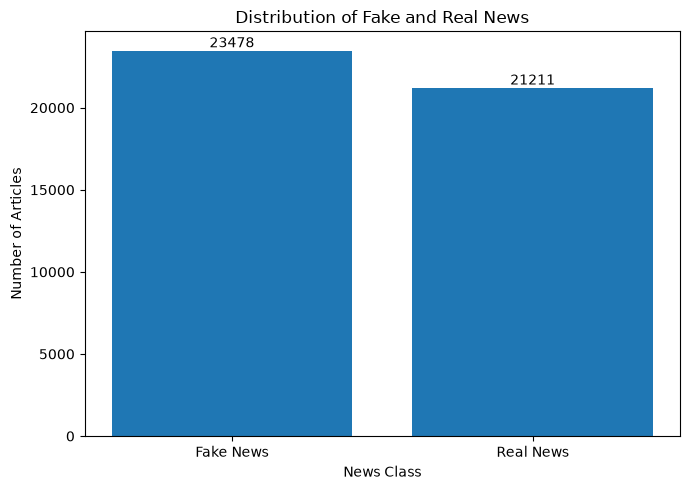

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

for index, value in enumerate(class_distribution["Count"]):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 6. Dataset Shuffling

The combined dataset is shuffled to mix Fake and Real news records. A fixed random state is used to ensure reproducible results.

In [14]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shuffled successfully.")
display(df[["content", "label"]].head())

Dataset shuffled successfully.


,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Rac...,0
